# DeepHit
A [DeepHit](https://ojs.aaai.org/index.php/AAAI/article/view/11842) model when we only have one event type.



In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# For preprocessing
from sklearn.preprocessing import StandardScaler

import torch # For building the networks 
import torchtuples as tt # Some useful functions

from pycox.datasets import metabric
from pycox.models import DeepHitSingle
from pycox.evaluation import EvalSurv

In [6]:
np.random.seed(1234)
_ = torch.manual_seed(123)

## Dataset
Loading preprocessed dataset about spanish SME

In [7]:
df = pd.read_csv('./../datasets/arhv_prepro_5.0.csv')
df

,N1,N2,N3,N4,N5,N6,N7,N8,N9,N10,...,F36,F37,F38,F39,F40,F41,F42,F43,event,time
0,0,0,1.0,1.0,0,0,0,0,0,0,...,0.104192,0.023926,1.305501,0.260649,0.122838,-0.060748,1.227461,-0.033476,0,21.0
1,0,40,2.0,1.0,1,0,0,2,0,0,...,0.187715,0.151417,0.626269,0.132299,0.251000,0.013268,-0.292335,-0.006962,0,22.0
2,0,18,2.0,1.0,0,0,0,0,0,0,...,0.385539,0.336895,1.361841,0.594791,0.949946,-0.011401,-1.925450,-0.017829,0,22.0
3,19,7,0.0,1.0,0,0,0,0,0,0,...,0.596548,0.407431,1.593357,0.224175,0.643866,0.031109,-0.442274,-0.027099,1,14.0
4,19,0,2.0,1.0,0,0,0,0,0,0,...,0.123080,0.117009,0.793149,0.381961,0.942754,0.003329,-0.745527,-0.009753,1,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6376,18,16,1.0,0.0,0,0,0,1,0,0,...,0.190463,0.168681,1.046977,0.091520,0.093166,-0.013568,-2.566817,-0.022228,1,9.0
6377,13,13,3.0,0.0,0,0,0,1,0,0,...,0.298466,0.133987,0.314466,0.145075,0.717814,0.065671,-0.155346,-0.015047,1,12.0
6378,11,11,1.0,0.0,0,0,0,1,0,0,...,0.124445,0.065487,0.977181,0.165864,0.017639,-0.008573,-1.151375,-0.043251,1,9.0
6379,9,5,1.0,0.0,0,0,0,0,0,0,...,0.000000,0.000000,0.522243,0.152878,-0.100963,-0.010897,-1.877954,-0.019716,1,15.0


In [8]:
df_train = df
df_test = df.sample(frac=0.2)
df_train = df_train.drop(df_test.index)
df_val = df_train.sample(frac=0.2)
df_train = df_train.drop(df_val.index)

print(f"Train dataset stats: {df_train.shape}, Validation datasets stats: {df_val.shape}, Test dataset stats: {df_test.shape}")

Train dataset stats: (4084, 45), Validation datasets stats: (1021, 45), Test dataset stats: (1276, 45)


In [9]:
df_train.head()

,N1,N2,N3,N4,N5,N6,N7,N8,N9,N10,...,F36,F37,F38,F39,F40,F41,F42,F43,event,time
0,0,0,1.0,1.0,0,0,0,0,0,0,...,0.104192,0.023926,1.305501,0.260649,0.122838,-0.060748,1.227461,-0.033476,0,21.0
1,0,40,2.0,1.0,1,0,0,2,0,0,...,0.187715,0.151417,0.626269,0.132299,0.251000,0.013268,-0.292335,-0.006962,0,22.0
2,0,18,2.0,1.0,0,0,0,0,0,0,...,0.385539,0.336895,1.361841,0.594791,0.949946,-0.011401,-1.925450,-0.017829,0,22.0
3,19,7,0.0,1.0,0,0,0,0,0,0,...,0.596548,0.407431,1.593357,0.224175,0.643866,0.031109,-0.442274,-0.027099,1,14.0
9,17,0,1.0,1.0,0,0,0,1,0,0,...,0.184629,0.098159,0.508884,0.184394,-0.056303,-0.022431,-3.495778,-0.031419,1,11.0


## Feature transforms

In [10]:
from sklearn.compose import ColumnTransformer
cols = df_train.columns.tolist()
cols.remove('event')
cols.remove('time')

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), cols)],
    remainder='passthrough',
    verbose_feature_names_out=False
)

x_train = preprocessor.fit_transform(df_train).astype('float32')
x_val = preprocessor.transform(df_val).astype('float32')
x_test = preprocessor.transform(df_test).astype('float32')

## Label transforms
The survival methods require individual `label transforms`, so we have included a proposed `label_transform` for each method. In this case `label_transform` is just a shorthand for the class pycox.preprocessing.label_transforms.LabTransDiscreteTime.

DeepHit is a discrete-time method, meaning it requires discretization of the event times to be applied to continuous-time data. We let `num_durations` define the size of this (equidistant) discretization grid, meaning our network will have num_durations output nodes.

In [12]:
num_durations = 10
labtrans = DeepHitSingle.label_transform(num_durations)
get_target = lambda df: (df['time'].values, df['event'].values)
y_train = labtrans.fit_transform(*get_target(df_train))
y_val = labtrans.transform(*get_target(df_val))

train = (x_train, y_train)
val = (x_val, y_val)

# We don't need to transform the test labels
durations_test, events_test = get_target(df_test)

In [13]:
type(labtrans)

pycox.preprocessing.label_transforms.LabTransDiscreteTime

### Neural Net
We make a neural net with `torch`. For simple network structures, we can use the `MLPVanilla` provided by `torchtuples`. 

The following net is an MLP with two hidden layers (with 32 nodes each), ReLU activations, and `num_nodes` output nodes. We also have batch normalization and dropout between the layers.

In [14]:
in_features = x_train.shape[1]
num_nodes = [32, 32]
out_features = labtrans.out_features
batch_norm = True
dropout = 0.1

net = tt.practical.MLPVanilla(in_features, num_nodes, out_features, batch_norm, dropout)

If you instead want to build this network with torch you can uncomment the following code. It is essentially equivalent to the MLPVanilla, but without the torch.nn.init.kaiming_normal_ weight initialization.

In [15]:
# net = torch.nn.Sequential(
#     torch.nn.Linear(in_features, 32),
#     torch.nn.ReLU(),
#     torch.nn.BatchNorm1d(32),
#     torch.nn.Dropout(0.1),
    
#     torch.nn.Linear(32, 32),
#     torch.nn.ReLU(),
#     torch.nn.BatchNorm1d(32),
#     torch.nn.Dropout(0.1),
    
#     torch.nn.Linear(32, out_features)
# )

### Training the model
To train the model we need to define an optimizer. You can choose any `torch.optim` optimizer, but here we instead use one from tt.optim as it has some added functionality. We use the `Adam` optimizer, but instead of choosing a learning rate, we will use the scheme proposed by [Smith 2017](https://arxiv.org/pdf/1506.01186.pdf) to find a suitable learning rate with `model.lr_finder`. See this post for an explanation.

We also set `duration_index` which connects the output nodes of the network the the discretization times. This is only useful for prediction and does not affect the training procedure.

DeepHit has a loss that is a combination of a negative log-likelihood and a ranking loss. `alpha` is a parameter that controls the linear combination between the two, and `sigma` is a parameter used by the ranking loss. `alpha = 1` give a loss only containing the negative log-likelihood and `alpha = 0` give a pure ranking loss. Note that this is different than the original paper.

In [16]:
model = DeepHitSingle(net, tt.optim.Adam, alpha=0.2, sigma=0.1, duration_index=labtrans.cuts)

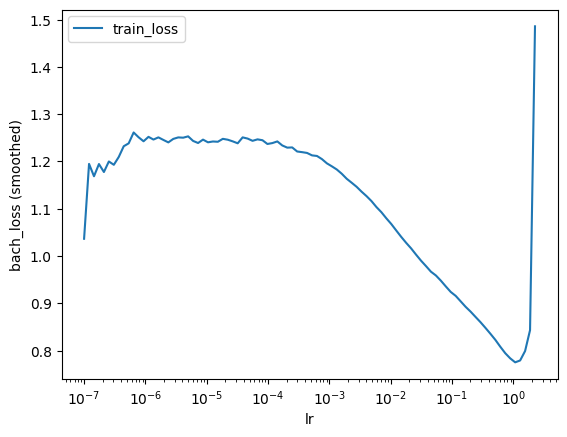

In [17]:
batch_size = 256
lr_finder = model.lr_finder(x_train, y_train, batch_size, tolerance=3)
_ = lr_finder.plot()

In [18]:
lr_finder.get_best_lr()

np.float64(0.10722672220103299)

Often, this learning rate is a little high, so we instead set it manually to 0.01

In [19]:
model.optimizer.set_lr(0.01)

We include the EarlyStopping callback to stop training when the validation loss stops improving. After training, this callback will also load the best performing model in terms of validation loss.

In [20]:
epochs = 100
callbacks = [tt.callbacks.EarlyStopping()]
log = model.fit(x_train, y_train, batch_size, epochs, callbacks, val_data=val)

0:	[0s / 0s],		train_loss: 0.6313,	val_loss: 0.4926
1:	[0s / 0s],		train_loss: 0.4415,	val_loss: 0.4135
2:	[0s / 0s],		train_loss: 0.3482,	val_loss: 0.2702
3:	[0s / 0s],		train_loss: 0.2446,	val_loss: 0.1637
4:	[0s / 0s],		train_loss: 0.1741,	val_loss: 0.1270
5:	[0s / 0s],		train_loss: 0.1352,	val_loss: 0.1104
6:	[0s / 0s],		train_loss: 0.1141,	val_loss: 0.0960
7:	[0s / 0s],		train_loss: 0.0986,	val_loss: 0.0830
8:	[0s / 0s],		train_loss: 0.0889,	val_loss: 0.0741
9:	[0s / 0s],		train_loss: 0.0817,	val_loss: 0.0679
10:	[0s / 0s],		train_loss: 0.0745,	val_loss: 0.0601
11:	[0s / 0s],		train_loss: 0.0697,	val_loss: 0.0563
12:	[0s / 1s],		train_loss: 0.0626,	val_loss: 0.0505
13:	[0s / 1s],		train_loss: 0.0585,	val_loss: 0.0463
14:	[0s / 1s],		train_loss: 0.0574,	val_loss: 0.0430
15:	[0s / 1s],		train_loss: 0.0566,	val_loss: 0.0440
16:	[0s / 1s],		train_loss: 0.0556,	val_loss: 0.0420
17:	[0s / 1s],		train_loss: 0.0560,	val_loss: 0.0402
18:	[0s / 1s],		train_loss: 0.0497,	val_loss: 0.0394
19:

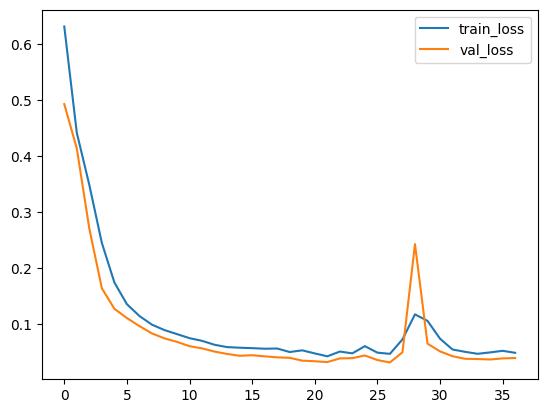

In [21]:
_ = log.plot()

## Prediction
For evaluation we first need to obtain survival estimates for the test set. This can be done with `model.predict_surv` which returns an array of survival estimates, or with `model.predict_surv_df` which returns the survival estimates as a dataframe.

In [23]:
surv = model.predict_surv_df(x_test)

We can plot the survival estimates for the first 5 individuals. Note that the time scale is correct because we have set `model.duration_index` to be the grid points. We have, however, only defined the survival estimates at the 10 times in our discretization grid, so, the survival estimates is a step function

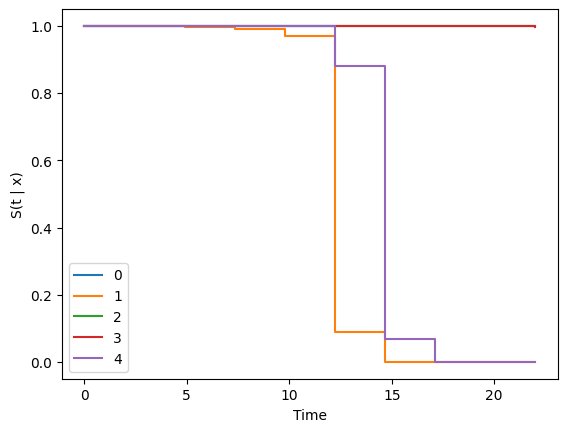

In [24]:
surv.iloc[:, :5].plot(drawstyle='steps-post')
plt.ylabel('S(t | x)')
_ = plt.xlabel('Time')

It is, therefore, often beneficial to interpolate the survival estimates, see [this paper](https://arxiv.org/abs/1910.06724) for a discussion. Linear interpolation (constant density interpolation) can be performed with the interpolate method. We also need to choose how many points we want to replace each grid point with. Her we will use 10.

In [25]:
surv = model.interpolate(10).predict_surv_df(x_test)

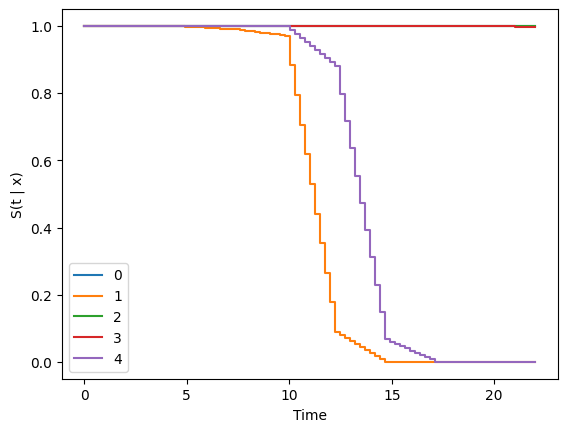

In [26]:
surv.iloc[:, :5].plot(drawstyle='steps-post')
plt.ylabel('S(t | x)')
_ = plt.xlabel('Time')

## Evaluation
The EvalSurv class contains some useful evaluation criteria for time-to-event prediction. We set censor_surv = 'km' to state that we want to use Kaplan-Meier for estimating the censoring distribution.

In [27]:
ev = EvalSurv(surv, durations_test, events_test, censor_surv='km')

### Concordance
We start with the event-time concordance by Antolini et al. 2005.